# EssentialGraph : crash et sortie fausse sur des DAG denses (agrum2 ET agrum3)

Deux defauts d'`EssentialGraph`, identiques dans les deux versions, observes sur des DAG valides denses :

1. **crash** — `Partially directed cycle detected` sur un DAG dont l'acyclicite est verifiee
   independamment (tri topologique en python pur) ;
2. **sortie fausse** — des arcs declares contraints (compelled) alors que le DAG n'a **aucun**
   collider non blinde : son graphe essentiel devrait etre son squelette, entierement non oriente
   (resultat classique, Andersson-Madigan-Perlman 1997).

Jamais observe sur les graphes creux du benchmark (densite 1.5) ; sur des DAG denses sans
v-structure tires au hasard, la sortie fausse touche ~3 cas sur 23. A signaler en annexe,
sans impact attendu sur les resultats du benchmark.

Run All avec un kernel agrum3 (cbnsl), puis avec un kernel agrum2 (venv) ; la derniere cellule compare.

In [1]:
import itertools
import json
from pathlib import Path

import pyagrum as gum
import pyagrum.lib.notebook as gnb

VERSION = f"agrum{gum.__version__.split('.')[0]}"
RESULTS = Path("/tmp/essentialgraph_bug")
RESULTS.mkdir(parents=True, exist_ok=True)

def bn_from(arcs, n):
    bn = gum.BayesNet()
    for i in range(n):
        bn.add(gum.LabelizedVariable(f"X{i}", "", 2))
    for t, h in arcs:
        bn.addArc(t, h)
    return bn

print(VERSION, "| pyagrum", gum.__version__)

agrum2 | pyagrum 2.3.0


DAG acyclique (tri topologique complet) : OK
agrum2 : EssentialGraph -> [pyAgrum] Partially directed cycle detected: Add a partial directed cycle in a PDAG : between 5 and 0


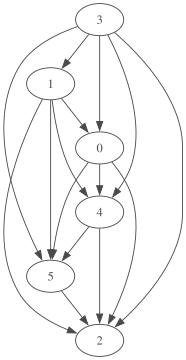

In [2]:
# Cas 1 : DAG valide (6 noeuds, 15 arcs) qui fait planter EssentialGraph.
ARCS_CRASH = [(0, 2), (0, 4), (0, 5), (1, 0), (1, 2), (1, 4), (1, 5),
              (3, 0), (3, 1), (3, 2), (3, 4), (3, 5), (4, 2), (4, 5), (5, 2)]

# acyclicite prouvee sans agrum : le tri topologique couvre les 6 noeuds
children = {i: set() for i in range(6)}
indeg = {i: 0 for i in range(6)}
for t, h in ARCS_CRASH:
    children[t].add(h); indeg[h] += 1
order = []
ready = [n for n in range(6) if indeg[n] == 0]
while ready:
    n = ready.pop()
    order.append(n)
    for c in children[n]:
        indeg[c] -= 1
        if indeg[c] == 0:
            ready.append(c)
assert len(order) == 6
print("DAG acyclique (tri topologique complet) : OK")

bn_crash = bn_from(ARCS_CRASH, 6)
try:
    eg_crash = gum.EssentialGraph(bn_crash)
    crash = "pas d'exception"
except Exception as e:
    crash = str(e).splitlines()[0]
print(f"{VERSION} : EssentialGraph -> {crash}")
gnb.showDot(bn_crash.dag().toDot())

In [3]:
# Cas 2 : DAG (5 noeuds) SANS collider non blinde.
# Son graphe essentiel attendu est son squelette, entierement non oriente.
ARCS_WRONG = [(1, 4), (3, 2), (1, 2), (3, 0), (1, 0), (2, 0), (0, 4), (2, 4), (3, 1)]
SKEL = {frozenset(a) for a in ARCS_WRONG}

parents = {i: set() for i in range(5)}
for t, h in ARCS_WRONG:
    parents[h].add(t)
colliders = [(a, c, b) for c in range(5)
             for a, b in itertools.combinations(sorted(parents[c]), 2)
             if frozenset((a, b)) not in SKEL]
assert not colliders
print("aucun collider non blinde dans ce DAG : OK")

bn_wrong = bn_from(ARCS_WRONG, 5)
eg = gum.EssentialGraph(bn_wrong)
p = eg.pdag()
out = {"cas1_crash": crash,
       "cas2_arcs": sorted([t, h] for t, h in p.arcs()),
       "cas2_edges": sorted([min(e), max(e)] for e in p.edges())}
(RESULTS / f"{VERSION}.json").write_text(json.dumps(out))
print(f"{VERSION} : arcs declares contraints : {out['cas2_arcs'] or 'aucun'} (attendu : aucun)")

aucun collider non blinde dans ce DAG : OK
agrum2 : arcs declares contraints : [[0, 4], [1, 4], [2, 4]] (attendu : aucun)


In [4]:
versions = sorted(f.stem for f in RESULTS.glob("agrum*.json"))
assert len(versions) == 2, "lancer d'abord ce notebook dans les deux kernels (cbnsl et venv)"

recomputed = {v: json.loads((RESULTS / f"{v}.json").read_text()) for v in versions}
print("sorties identiques entre les deux versions :",
      recomputed["agrum2"] == recomputed["agrum3"])
for v in versions:
    r = recomputed[v]
    ok = not r["cas2_arcs"]
    print(f"{v} : cas 1 (crash)  : {r['cas1_crash']}")
    print(f"{v} : cas 2 (sortie) : arcs contraints {r['cas2_arcs']} -> "
          f"{'OK' if ok else 'FAUX (attendu : aucun)'}")

def pdag_from(arcs, edges, n):
    pd = gum.PDAG()
    for i in range(n):
        pd.addNodeWithId(i)
    for t, h in arcs:
        pd.addArc(t, h)
    for u, v in edges:
        pd.addEdge(u, v)
    return pd

r3 = recomputed["agrum3"]
expected = pdag_from([], sorted([min(e), max(e)] for e in SKEL), 5)
gnb.sideBySide(
    gnb.getDot(bn_wrong.dag().toDot()),
    gnb.getDot(expected.toDot()),
    gnb.getDot(pdag_from(r3["cas2_arcs"], r3["cas2_edges"], 5).toDot()),
    captions=["cas 2 : DAG sans collider non blinde",
              "graphe essentiel attendu\n(= squelette non oriente)",
              "EssentialGraph obtenu (agrum2 = agrum3)\nFAUX : arcs contraints inventes"])

sorties identiques entre les deux versions : True
agrum2 : cas 1 (crash)  : [pyAgrum] Partially directed cycle detected: Add a partial directed cycle in a PDAG : between 5 and 0
agrum2 : cas 2 (sortie) : arcs contraints [[0, 4], [1, 4], [2, 4]] -> FAUX (attendu : aucun)
agrum3 : cas 1 (crash)  : [pyAgrum] Partially directed cycle detected: Add a partial directed cycle in a PDAG : between 5 and 0
agrum3 : cas 2 (sortie) : arcs contraints [[0, 4], [1, 4], [2, 4]] -> FAUX (attendu : aucun)


no_name cluster_0 <!-- 3 --> 3 3 <!-- 1 --> 1 1 <!-- 1->3 --> 1->3 <!-- 4 --> 4 4 <!-- 1->4 --> 1->4 <!-- 2 --> 2 2 <!-- 1->2 --> 1->2 <!-- 0 --> 0 0 <!-- 0->3 --> 0->3 <!-- 0->1 --> 0->1 <!-- 0->4 --> 0->4 <!-- 0->2 --> 0->2 <!-- 2->3 --> 2->3 <!-- 2->4 --> 2->4 graphe essentiel attendu (= squelette non oriente),no_name cluster_0 <!-- 4 --> 4 4 <!-- 3 --> 3 3 <!-- 1 --> 1 1 <!-- 1->4 --> 1->4 <!-- 1->3 --> 1->3 <!-- 2 --> 2 2 <!-- 1->2 --> 1->2 <!-- 0 --> 0 0 <!-- 0->4 --> 0->4 <!-- 0->3 --> 0->3 <!-- 0->1 --> 0->1 <!-- 0->2 --> 0->2 <!-- 2->4 --> 2->4 <!-- 2->3 --> 2->3 EssentialGraph obtenu (agrum2 = agrum3) FAUX : arcs contraints inventes
